# Cross-Market Arbitrage & Order Book Strategies

**Goal:** Exploit pricing inconsistencies across Kalshi's correlated NBA markets and order book microstructure.

## Strategies explored:
1. **Cross-market arbitrage** — KXNBASPREAD CDF implies P(win); compare to KXNBAGAME price
2. **Order book analysis** — spread/depth, imbalance signals, passive fill opportunities
3. **Player prop staleness** — props reprice slower than game market after PBP events (latency arb)

## Data available:
- Historical trades: KXNBAGAME (1902), KXNBASPREAD (8923), KXNBATOTAL (9044), KXNBAPTS (8876), KXNBA3PT (7804)
- Live order book: snapshots + deltas (Apr 18-20, 2026)
- NBA CDN play-by-play: 1230 regular season games
- Live bronze trades: ~20k+ WS trades

In [64]:
import json
import gzip
import re
import gc
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

s3 = boto3.client("s3")
S3_BUCKET = "prediction-markets-data"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 1. Cross-Market Arbitrage: KXNBASPREAD → Implied P(Win) vs KXNBAGAME

### The two contracts

Both markets are binary ($0 or $1 at settlement). For a given game, say **LAL vs DAL**:

| Contract | Pays $1 if... | Probability of payoff |
|---|---|---|
| `KXNBAGAME-LAL` (YES) | LAL wins the game | `P(LAL wins)` |
| `KXNBASPREAD-LAL-1.5` (YES) | LAL wins by **2 or more** points | `P(LAL wins by ≥2)` |

The spread contract is *strictly harder to win* than the game contract, because it excludes the case "LAL wins by exactly 1 point." So by basic probability:

```
P(LAL wins)  =  P(LAL wins by ≥2)  +  P(LAL wins by exactly 1)
```

Kalshi prices are (roughly) probabilities in cents, so in a fair market:

```
price(GAME-LAL)  =  price(SPREAD-LAL-1.5)  +  P(1-point win)
                 ≈  price(SPREAD-LAL-1.5)  +  2–3¢
```

That **2–3¢ gap is the only structurally justifiable price difference** between the two. In NBA history, roughly 2–3% of games are decided by exactly 1 point, so if GAME trades 2–3¢ above SPREAD@1.5, everyone is priced fairly.

### Where the arb comes from

Now suppose at some moment during the game, the quotes look like this:

```
GAME-LAL         : 0.68  ← implied P(win) = 68%
SPREAD-LAL-1.5   : 0.63  ← implied P(win by ≥2) = 63%
gap              : 0.05  ← 5¢
```

The gap is 5¢, but the *true* gap (the 1-point-win probability) is only ~2¢. So **one of these two prices is wrong by ~3¢**. We don't need to know *which one*. The arb doesn't care — it just trades the spread between them.

### The trade (when gap is too wide)

Gap of 5¢ means GAME is too expensive relative to SPREAD, OR SPREAD is too cheap relative to GAME. Either way:

- **Sell GAME-LAL YES @ 0.68** (or equivalently, buy NO @ 0.32)
- **Buy SPREAD-LAL-1.5 YES @ 0.63**

Now look at what happens at settlement in each possible outcome:

| Game outcome | GAME YES pays | SPREAD YES pays | Net P&L per pair |
|---|---|---|---|
| LAL wins by ≥2 | $1 (we owe it) | $1 (we collect it) | `-1 + 1 + (0.68 - 0.63) = +$0.05` |
| LAL wins by exactly 1 | $1 (we owe it) | $0 | `-1 + 0 + (0.68 - 0.63) = -$0.95` |
| LAL loses | $0 | $0 | `0 + 0 + (0.68 - 0.63) = +$0.05` |

So in **two of three outcome categories we make 5¢**, and in the (rare) 1-point-win case we lose 95¢. Expected value:

```
E[P&L] = 0.05 × P(not a 1-point LAL win) - 0.95 × P(1-point LAL win)
       ≈ 0.05 × 0.98           -  0.95 × 0.02
       ≈ +0.049                -  0.019
       ≈ +0.030 per contract pair
```

Positive EV of ~3¢ per contract, which is exactly the mispricing we identified. Scale up → repeat across many games → collect the edge.

### Why this isn't free money

- **It's not a true arb, it's a statistical arb.** There *is* a path where you lose (the 1-point game). The edge only materializes over many trades. Sequence one bad 1-point game before you've diversified and you're underwater.
- **Fees and the spread eat you alive.** Kalshi fees plus the bid-ask round trip can easily cost 2–4¢ per pair. You need the gap to be materially *wider* than both the 2¢ fundamental gap **and** transaction costs before entering.
- **You need to trade both legs.** If you only get filled on one leg, you have directional exposure instead of arb — now you're just betting on the game.

### Temporal, not structural

At **settlement**, GAME and SPREAD@1.5 always reconcile (to within the 1-point probability) — that's the law of the payoffs above. So any wide gap you see during a game is a *temporary* dislocation: one market saw new information (a scoring run, an injury, a lead change) and repriced faster than the other. The mispricing closes on its own, usually within seconds to minutes.

The strategy is therefore a **convergence trade**: enter when the gap opens wider than ~fundamental + fees, exit when it closes (or hold to settlement). You are not discovering a permanent flaw in contract design — you are supplying liquidity between two correlated pools that temporarily disagree.

### What this notebook section measures

The cells below quantify: (1) how often the gap exceeds a tradeable threshold, (2) how long it persists before closing, (3) what the realized P&L looks like net of realistic fills and fees. Those numbers determine whether this is a real strategy or a textbook curiosity.


In [65]:
# Load all KXNBAGAME and KXNBASPREAD markets
obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBAGAME.json")
game_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBAGAME: {len(game_markets)} markets")

obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBASPREAD.json")
spread_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBASPREAD: {len(spread_markets)} markets")

# Parse event_ticker to extract game info
# KXNBAGAME: event_ticker = "KXNBAGAME-25DEC25MINDEN", ticker = "KXNBAGAME-25DEC25MINDEN-DEN"
# KXNBASPREAD: event_ticker = "KXNBASPREAD-25DEC25MINDEN", ticker = "KXNBASPREAD-25DEC25MINDEN-DEN7"

# Extract the game key (date + teams) from event_ticker
def game_key_from_event(event_ticker, prefix):
    """Extract 'YYMMMDDAWYHOM' from event_ticker, e.g., '25DEC25MINDEN'"""
    return event_ticker.replace(prefix + "-", "")

game_markets["game_key"] = game_markets["event_ticker"].apply(lambda x: game_key_from_event(x, "KXNBAGAME"))
spread_markets["game_key"] = spread_markets["event_ticker"].apply(lambda x: game_key_from_event(x, "KXNBASPREAD"))

# Find games that exist in both markets
common_games = set(game_markets["game_key"]) & set(spread_markets["game_key"])
print(f"\nGames in both GAME and SPREAD markets: {len(common_games)}")

# Parse spread strike from ticker
# e.g., "KXNBASPREAD-25DEC25MINDEN-DEN7" → team=DEN, strike=7 → "DEN wins by >7.5"
def parse_spread_ticker(ticker):
    parts = ticker.split("-")
    team_strike = parts[-1]  # e.g., "DEN7" or "MIN3"
    match = re.match(r"([A-Z]+)(\d+)", team_strike)
    if match:
        team = match.group(1)
        strike = int(match.group(2)) + 0.5  # strikes are X.5
        return team, strike
    return None, None

spread_markets[["strike_team", "strike_val"]] = spread_markets["ticker"].apply(
    lambda x: pd.Series(parse_spread_ticker(x))
)
print(f"\nSpread market strike distribution:")
print(spread_markets["strike_val"].describe())

KXNBAGAME: 1902 markets
KXNBASPREAD: 8923 markets

Games in both GAME and SPREAD markets: 821

Spread market strike distribution:
count    8923.000000
mean       10.532500
std         6.591268
min         1.500000
25%         5.500000
50%         9.500000
75%        14.500000
max        34.500000
Name: strike_val, dtype: float64


In [66]:
# For each game, compare KXNBAGAME last_price vs KXNBASPREAD lowest-strike implied P(win)
# The spread market "Team wins by >1.5" ≈ P(team wins) in NBA (no ties, 1-point wins are ~2%)

# Get KXNBAGAME prices per game (home team market)
# Each game has 2 markets (home + away team), prices should sum to ~$1.00
game_by_event = game_markets.groupby("event_ticker").apply(
    lambda g: pd.Series({
        "game_key": g["game_key"].iloc[0],
        "tickers": list(g["ticker"]),
        "prices": list(g["last_price_dollars"].astype(float)),
        "expiration_values": list(g["expiration_value"]),
    })
).reset_index()

print(f"KXNBAGAME events: {len(game_by_event)}")
print(f"Price sum distribution (should be ~1.0):")
game_by_event["price_sum"] = game_by_event["prices"].apply(sum)
print(game_by_event["price_sum"].describe())

# For spread: find the lowest strike for each team in each game
# "Team wins by >1.5" is the closest to "team wins"
spread_low = spread_markets[spread_markets["strike_val"] <= 2.5].copy()
print(f"\nSpread markets with strike <= 2.5: {len(spread_low)}")
print(spread_low.groupby("game_key").size().describe())

KXNBAGAME events: 951
Price sum distribution (should be ~1.0):
count    951.000000
mean       0.999968
std        0.001919
min        0.960000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.030000
Name: price_sum, dtype: float64

Spread markets with strike <= 2.5: 1143
count    570.000000
mean       2.005263
std        0.217770
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
dtype: float64


In [67]:
# Load trades for paired GAME + SPREAD markets and compare prices over time
# Pick games with high volume for clearer signal

# Strategy: for each game, load trades from KXNBAGAME-{key}-{team} and KXNBASPREAD-{key}-{team}1
# (the "wins by >1.5" strike), align on time, measure divergence

def load_trades(ticker):
    """Load historical trades for a ticker from S3."""
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{ticker}.json")
        trades = json.loads(obj["Body"].read())
        df = pd.DataFrame(trades)
        if not df.empty:
            df["created_time"] = pd.to_datetime(df["created_time"])
            df["yes_price"] = df["yes_price_dollars"].astype(float)
        return df
    except Exception:
        return pd.DataFrame()

# Find games where both GAME and SPREAD "wins by 1.5" exist
# Build pairs: (game_ticker, spread_ticker_1.5) for each team in each game
pairs = []
for game_key in list(common_games)[:200]:  # sample 200 games
    # Get game market tickers for this game
    gm = game_markets[game_markets["game_key"] == game_key]
    # Get spread markets with strike 1.5 for this game
    sm = spread_markets[(spread_markets["game_key"] == game_key) & (spread_markets["strike_val"] == 1.5)]
    
    for _, grow in gm.iterrows():
        # Extract team from game ticker (last segment)
        game_team = grow["ticker"].split("-")[-1]
        # Find matching spread ticker for same team
        matching_spread = sm[sm["strike_team"] == game_team]
        if not matching_spread.empty:
            pairs.append({
                "game_key": game_key,
                "team": game_team,
                "game_ticker": grow["ticker"],
                "spread_ticker": matching_spread.iloc[0]["ticker"],
                "game_last_price": float(grow["last_price_dollars"]),
                "spread_last_price": float(matching_spread.iloc[0]["last_price_dollars"]),
            })

pairs_df = pd.DataFrame(pairs)
print(f"Found {len(pairs_df)} GAME↔SPREAD(1.5) pairs across {pairs_df['game_key'].nunique()} games")

# Compare last prices
pairs_df["price_diff"] = pairs_df["game_last_price"] - pairs_df["spread_last_price"]
print(f"\nLast price difference (GAME - SPREAD@1.5):")
print(pairs_df["price_diff"].describe())
print(f"\n|diff| > 0.03: {(pairs_df['price_diff'].abs() > 0.03).sum()} pairs")
print(f"|diff| > 0.05: {(pairs_df['price_diff'].abs() > 0.05).sum()} pairs")

Found 139 GAME↔SPREAD(1.5) pairs across 138 games

Last price difference (GAME - SPREAD@1.5):
count    139.000000
mean       0.006547
std        0.083481
min       -0.080000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.980000
Name: price_diff, dtype: float64

|diff| > 0.03: 2 pairs
|diff| > 0.05: 2 pairs


In [68]:
# Time-series comparison: load trades for top divergent pairs and measure intra-game spread
# Pick the pairs with largest |price_diff| at settlement

top_pairs = pairs_df.nlargest(20, "price_diff", keep="first").head(10)
print("Top 10 divergent pairs (GAME price > SPREAD@1.5 price):")
print(top_pairs[["game_key", "team", "game_last_price", "spread_last_price", "price_diff"]].to_string())

# Load intra-game trade series for a few high-divergence pairs
def load_pair_trades(row):
    game_trades = load_trades(row["game_ticker"])
    spread_trades = load_trades(row["spread_ticker"])
    return game_trades, spread_trades

# Load trades for top 5 pairs
print("\n\nLoading trade time series for top divergent pairs...")
pair_series = []
for idx, row in top_pairs.head(5).iterrows():
    gt, st = load_pair_trades(row)
    if not gt.empty and not st.empty:
        pair_series.append({
            "game_key": row["game_key"],
            "team": row["team"],
            "game_trades": gt,
            "spread_trades": st,
            "game_ticker": row["game_ticker"],
            "spread_ticker": row["spread_ticker"],
        })
        print(f"  {row['game_key']} {row['team']}: {len(gt)} game trades, {len(st)} spread trades")

print(f"\nLoaded {len(pair_series)} pairs with trade data")

Top 10 divergent pairs (GAME price > SPREAD@1.5 price):
          game_key team  game_last_price  spread_last_price  price_diff
66   26JAN05GSWLAC  LAC             0.99               0.01        0.98
35   25DEC22MEMOKC  OKC             0.99               0.97        0.02
115  26JAN25DENMEM  DEN             0.48               0.47        0.01
0    26JAN20LALDEN  DEN             0.01               0.01        0.00
1    25DEC01DALDEN  DEN             0.01               0.01        0.00
2    25DEC31MINATL  MIN             0.01               0.01        0.00
3    26FEB02PHILAC  PHI             0.99               0.99        0.00
4    25DEC20PORSAC  SAC             0.01               0.01        0.00
5    25DEC02WASPHI  PHI             0.99               0.99        0.00
6    25DEC04MINNOP  NOP             0.01               0.01        0.00


Loading trade time series for top divergent pairs...
  26JAN05GSWLAC LAC: 20294 game trades, 1736 spread trades
  25DEC22MEMOKC OKC: 4332 game trades,

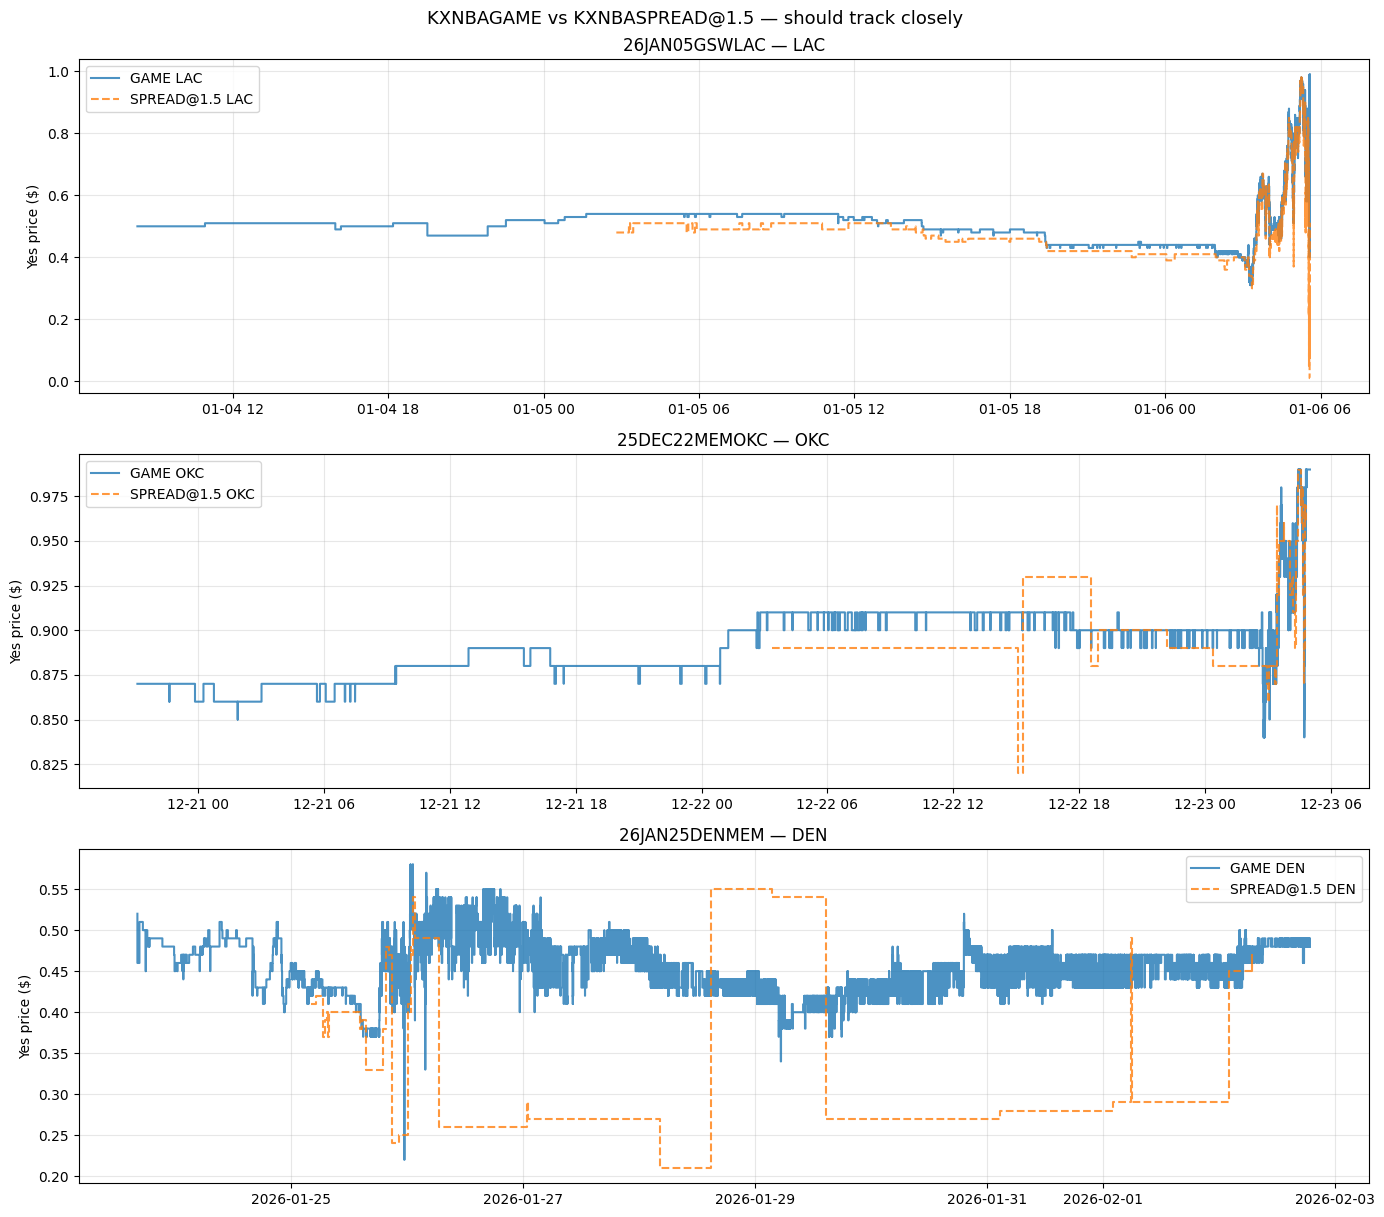

In [69]:
# Plot GAME vs SPREAD@1.5 price over time for divergent pairs
fig, axes = plt.subplots(min(len(pair_series), 3), 1, figsize=(14, 4*min(len(pair_series), 3)), squeeze=False)

for i, ps in enumerate(pair_series[:3]):
    ax = axes[i, 0]
    gt = ps["game_trades"].sort_values("created_time")
    st = ps["spread_trades"].sort_values("created_time")
    
    ax.step(gt["created_time"], gt["yes_price"], where="post", label=f"GAME {ps['team']}", alpha=0.8)
    ax.step(st["created_time"], st["yes_price"], where="post", label=f"SPREAD@1.5 {ps['team']}", alpha=0.8, linestyle="--")
    ax.set_title(f"{ps['game_key']} — {ps['team']}")
    ax.set_ylabel("Yes price ($)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("KXNBAGAME vs KXNBASPREAD@1.5 — should track closely", y=1.01, fontsize=13)
plt.show()

In [70]:
# Systematic cross-market divergence measurement
# For each pair, align trades on 30-second bins and measure price gap over time

def measure_divergence_over_time(game_trades, spread_trades, freq="30s"):
    """Resample both trade series to common frequency, measure gap."""
    if game_trades.empty or spread_trades.empty:
        return pd.DataFrame()
    
    gt = game_trades.set_index("created_time")["yes_price"].resample(freq).last().ffill()
    st = spread_trades.set_index("created_time")["yes_price"].resample(freq).last().ffill()
    
    # Align on common timestamps
    combined = pd.DataFrame({"game_price": gt, "spread_price": st}).dropna()
    if combined.empty:
        return combined
    
    combined["divergence"] = combined["game_price"] - combined["spread_price"]
    return combined

# Measure across all loaded pairs
all_divergences = []
for ps in pair_series:
    div = measure_divergence_over_time(ps["game_trades"], ps["spread_trades"])
    if not div.empty:
        all_divergences.append(div["divergence"])
        
if all_divergences:
    all_div = pd.concat(all_divergences)
    print(f"Cross-market divergence (GAME - SPREAD@1.5), 30s bins:")
    print(f"  Observations: {len(all_div)}")
    print(f"  Mean:   {all_div.mean():.4f}")
    print(f"  Std:    {all_div.std():.4f}")
    print(f"  Median: {all_div.median():.4f}")
    print(f"  |div| > $0.02: {(all_div.abs() > 0.02).mean():.1%} of observations")
    print(f"  |div| > $0.03: {(all_div.abs() > 0.03).mean():.1%} of observations")
    print(f"  |div| > $0.05: {(all_div.abs() > 0.05).mean():.1%} of observations")

# Now do the same at scale — load many more pairs
print("\n\nScaling up: loading trades for 50 random common games...")
import random
sample_games = random.sample(list(common_games), min(50, len(common_games)))

scale_divergences = []
loaded = 0
for game_key in sample_games:
    gm = game_markets[game_markets["game_key"] == game_key]
    sm = spread_markets[(spread_markets["game_key"] == game_key) & (spread_markets["strike_val"] == 1.5)]
    
    for _, grow in gm.iterrows():
        game_team = grow["ticker"].split("-")[-1]
        matching_spread = sm[sm["strike_team"] == game_team]
        if not matching_spread.empty:
            gt = load_trades(grow["ticker"])
            st = load_trades(matching_spread.iloc[0]["ticker"])
            div = measure_divergence_over_time(gt, st)
            if not div.empty:
                scale_divergences.append(div["divergence"])
                loaded += 1
    if loaded >= 50:
        break

if scale_divergences:
    all_div_scale = pd.concat(scale_divergences)
    print(f"\n  Loaded {loaded} pairs, {len(all_div_scale)} time-aligned observations")
    print(f"  Mean divergence:  {all_div_scale.mean():.4f}")
    print(f"  Std:              {all_div_scale.std():.4f}")
    print(f"  |div| > $0.02:   {(all_div_scale.abs() > 0.02).mean():.1%}")
    print(f"  |div| > $0.03:   {(all_div_scale.abs() > 0.03).mean():.1%}")
    print(f"  |div| > $0.05:   {(all_div_scale.abs() > 0.05).mean():.1%}")
    print(f"  Max |div|:       ${all_div_scale.abs().max():.3f}")

Cross-market divergence (GAME - SPREAD@1.5), 30s bins:
  Observations: 33288
  Mean:   0.0964
  Std:    0.1099
  Median: 0.1400
  |div| > $0.02: 89.2% of observations
  |div| > $0.03: 74.7% of observations
  |div| > $0.05: 63.6% of observations


Scaling up: loading trades for 50 random common games...

  Loaded 35 pairs, 63689 time-aligned observations
  Mean divergence:  0.0305
  Std:              0.0756
  |div| > $0.02:   65.6%
  |div| > $0.03:   44.1%
  |div| > $0.05:   18.9%
  Max |div|:       $0.730


In [71]:
# Cross-market arb backtest
# When |GAME - SPREAD@1.5| > threshold, buy the cheap one and sell the expensive one
# Both settle to same outcome (team wins or not), so guaranteed convergence at expiry

ARB_THRESHOLD = 0.03  # only trade when gap > 3 cents
ARB_FEE = 0.02  # fee per leg (2 legs = $0.04 total)

arb_trades = []
for div_series in scale_divergences:
    for ts, div_val in div_series.items():
        if abs(div_val) > ARB_THRESHOLD:
            # If GAME > SPREAD: sell GAME, buy SPREAD (both settle same)
            # Profit = |divergence| - 2*fee at expiry
            pnl = abs(div_val) - 2 * ARB_FEE
            arb_trades.append({
                "time": ts,
                "divergence": div_val,
                "direction": "sell_game" if div_val > 0 else "buy_game",
                "pnl": pnl,
            })

if arb_trades:
    arb_df = pd.DataFrame(arb_trades)
    print(f"CROSS-MARKET ARB BACKTEST (threshold={ARB_THRESHOLD}, fee={ARB_FEE}/leg)")
    print("=" * 70)
    print(f"  Signals: {len(arb_df)}")
    print(f"  Win rate: {(arb_df['pnl'] > 0).mean():.1%}")
    print(f"  Mean PnL/trade: ${arb_df['pnl'].mean():.4f}")
    print(f"  Total PnL: ${arb_df['pnl'].sum():.2f}")
    print(f"  Mean |divergence|: ${arb_df['divergence'].abs().mean():.4f}")
    print(f"  Sharpe: {arb_df['pnl'].mean() / arb_df['pnl'].std():.2f}" if arb_df['pnl'].std() > 0 else "")
    print(f"\n  By direction:")
    for d, grp in arb_df.groupby("direction"):
        print(f"    {d}: {len(grp)} trades, mean PnL ${grp['pnl'].mean():.4f}")
    
    # NOTE: This assumes we can execute at the observed divergence (no slippage).
    # In reality, we'd need to cross the spread on both legs simultaneously.
    # The order book analysis below tells us if this is feasible.
else:
    print("No arb signals found at this threshold — markets are well-linked.")

CROSS-MARKET ARB BACKTEST (threshold=0.03, fee=0.02/leg)
  Signals: 28089
  Win rate: 62.5%
  Mean PnL/trade: $0.0339
  Total PnL: $950.97
  Mean |divergence|: $0.0739
  Sharpe: 0.35

  By direction:
    buy_game: 3025 trades, mean PnL $0.0606
    sell_game: 25064 trades, mean PnL $0.0306


## 2. Order Book Analysis

Using live order book snapshots + deltas to understand:
- Typical bid-ask spread (can we execute passively?)
- Depth at top of book (how much size can we trade?)
- Book imbalance as a directional signal

In [72]:
# Load all order book snapshots
paginator = s3.get_paginator("list_objects_v2")
snap_keys = []
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix="bronze/kalshi_ws/orderbook_snapshot/"):
    snap_keys.extend([o["Key"] for o in page.get("Contents", [])])
print(f"Order book snapshot files: {len(snap_keys)}")

# Parse all snapshots
snapshots = []
for key in snap_keys:
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    data = gzip.decompress(obj["Body"].read()).decode()
    for line in data.strip().split("\n"):
        rec = json.loads(line)
        msg = rec["frame"]["msg"]
        
        # Parse the book: yes_dollars_fp is the bid side, no_dollars_fp is the ask
        # Format: [[price, size], ...]
        yes_levels = msg.get("yes_dollars_fp", [])
        no_levels = msg.get("no_dollars_fp", [])
        
        # Best bid = highest yes price with size, best ask = 1 - highest no price with size
        # On Kalshi: yes_bid is what buyers will pay for YES
        # no_bid is what buyers will pay for NO = (1 - ask_for_yes)
        best_yes_bid = max([float(p) for p, s in yes_levels]) if yes_levels else None
        best_no_bid = max([float(p) for p, s in no_levels]) if no_levels else None
        best_yes_ask = 1.0 - best_no_bid if best_no_bid else None
        
        # Total depth
        yes_depth = sum(float(s) for p, s in yes_levels) if yes_levels else 0
        no_depth = sum(float(s) for p, s in no_levels) if no_levels else 0
        
        # Top-of-book depth (at best price)
        top_yes_size = float(yes_levels[-1][1]) if yes_levels else 0  # levels sorted asc
        best_yes_price_level = max(yes_levels, key=lambda x: float(x[0])) if yes_levels else None
        top_bid_size = float(best_yes_price_level[1]) if best_yes_price_level else 0
        
        snapshots.append({
            "t_receipt": rec["t_receipt"],
            "ticker": msg["market_ticker"],
            "best_bid": best_yes_bid,
            "best_ask": best_yes_ask,
            "spread": (best_yes_ask - best_yes_bid) if (best_yes_ask and best_yes_bid) else None,
            "yes_depth": yes_depth,
            "no_depth": no_depth,
            "bid_depth_top": top_bid_size,
            "n_yes_levels": len(yes_levels),
            "n_no_levels": len(no_levels),
        })

snap_df = pd.DataFrame(snapshots)
snap_df["t_receipt_dt"] = pd.to_datetime(snap_df["t_receipt"], unit="s", utc=True)
print(f"\nParsed {len(snap_df)} order book snapshots across {snap_df['ticker'].nunique()} tickers")
print(f"Time range: {snap_df['t_receipt_dt'].min()} to {snap_df['t_receipt_dt'].max()}")

Order book snapshot files: 39

Parsed 6444 order book snapshots across 906 tickers
Time range: 2026-04-18 23:21:03.750926256+00:00 to 2026-04-20 04:58:42.553514957+00:00


BID-ASK SPREAD ANALYSIS
  Valid observations: 5738
  Mean spread: $0.0470
  Median spread: $0.0300
  p25: $0.0200
  p75: $0.0400
  Spread <= $0.01: 6.2%
  Spread <= $0.02: 29.3%
  Spread <= $0.03: 52.4%

Spread by market series:
  KXNBAGAME      : median $0.020, mean $0.033, n=872
  KXNBAPTS       : median $0.030, mean $0.055, n=2942
  KXNBASPREAD    : median $0.020, mean $0.027, n=942
  KXNBATOTAL     : median $0.020, mean $0.056, n=982

TOP-OF-BOOK DEPTH (yes side):
  Mean: $5,818
  Median: $360


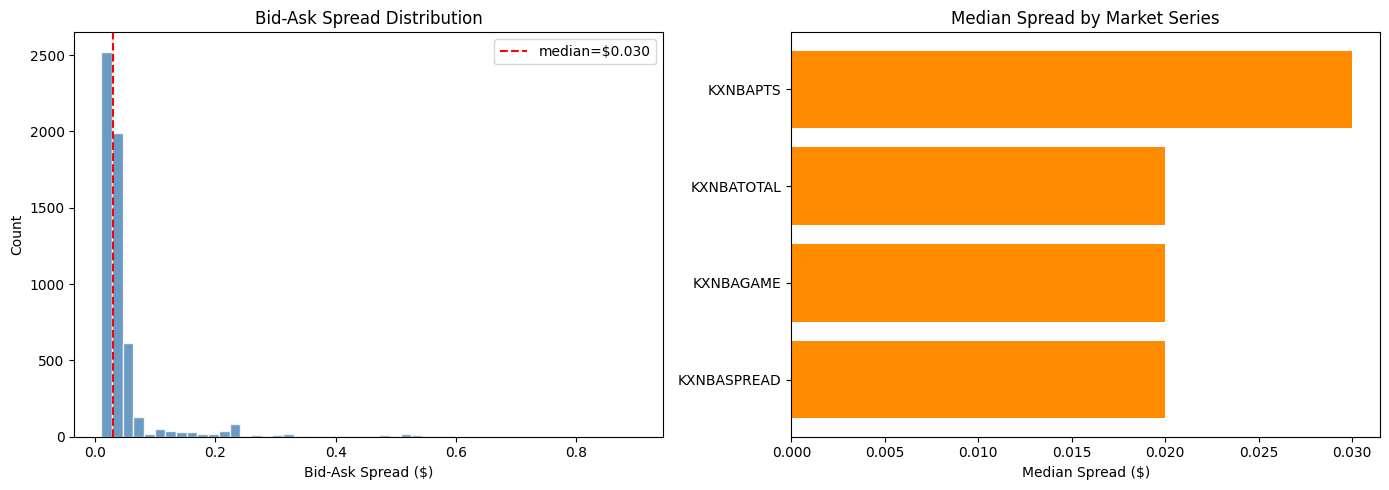

In [73]:
# Bid-ask spread analysis
valid_spreads = snap_df[snap_df["spread"].notna() & (snap_df["spread"] > 0)]
print("BID-ASK SPREAD ANALYSIS")
print("=" * 60)
print(f"  Valid observations: {len(valid_spreads)}")
print(f"  Mean spread: ${valid_spreads['spread'].mean():.4f}")
print(f"  Median spread: ${valid_spreads['spread'].median():.4f}")
print(f"  p25: ${valid_spreads['spread'].quantile(0.25):.4f}")
print(f"  p75: ${valid_spreads['spread'].quantile(0.75):.4f}")
print(f"  Spread <= $0.01: {(valid_spreads['spread'] <= 0.01).mean():.1%}")
print(f"  Spread <= $0.02: {(valid_spreads['spread'] <= 0.02).mean():.1%}")
print(f"  Spread <= $0.03: {(valid_spreads['spread'] <= 0.03).mean():.1%}")

# By market type (GAME vs SPREAD vs TOTAL vs player props)
valid_spreads = valid_spreads.copy()
valid_spreads["series"] = valid_spreads["ticker"].apply(
    lambda t: re.match(r"(KXNBA\w+?)-", t).group(1) if re.match(r"(KXNBA\w+?)-", t) else "unknown"
)
print(f"\nSpread by market series:")
for series, grp in valid_spreads.groupby("series"):
    print(f"  {series:15s}: median ${grp['spread'].median():.3f}, "
          f"mean ${grp['spread'].mean():.3f}, n={len(grp)}")

# Depth at top of book
print(f"\nTOP-OF-BOOK DEPTH (yes side):")
print(f"  Mean: ${valid_spreads['bid_depth_top'].mean():,.0f}")
print(f"  Median: ${valid_spreads['bid_depth_top'].median():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(valid_spreads["spread"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(valid_spreads["spread"].median(), color="red", linestyle="--", 
                label=f"median=${valid_spreads['spread'].median():.3f}")
axes[0].set_xlabel("Bid-Ask Spread ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Bid-Ask Spread Distribution")
axes[0].legend()

# Spread by series
series_medians = valid_spreads.groupby("series")["spread"].median().sort_values()
axes[1].barh(series_medians.index, series_medians.values, color="darkorange")
axes[1].set_xlabel("Median Spread ($)")
axes[1].set_title("Median Spread by Market Series")
plt.tight_layout()
plt.show()

In [74]:
# Order book imbalance as directional signal
# Imbalance = (yes_depth - no_depth) / (yes_depth + no_depth)
# Hypothesis: when yes side is thicker, price is more likely to move up (more buyers waiting)

snap_df["imbalance"] = (snap_df["yes_depth"] - snap_df["no_depth"]) / (snap_df["yes_depth"] + snap_df["no_depth"] + 1)

# To test: pair snapshots with subsequent trade prices
# Load trade data to measure price movement after each snapshot
print("Loading live WS trades for order book imbalance analysis...")

# Load bronze trades
paginator = s3.get_paginator("list_objects_v2")
trade_keys = []
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix="bronze/kalshi_ws/trade/"):
    trade_keys.extend([o["Key"] for o in page.get("Contents", [])])
    if len(trade_keys) >= 200:
        break

print(f"Loading {min(len(trade_keys), 100)} trade files...")
ws_trades = []
for key in trade_keys[:100]:
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    data = gzip.decompress(obj["Body"].read()).decode()
    for line in data.strip().split("\n"):
        rec = json.loads(line)
        msg = rec["frame"]["msg"]
        ws_trades.append({
            "t_receipt": rec["t_receipt"],
            "ticker": msg.get("market_ticker", ""),
            "yes_price": float(msg["yes_price_dollars"]) if "yes_price_dollars" in msg else None,
            "ts": msg.get("ts", ""),
        })

ws_trades_df = pd.DataFrame(ws_trades)
ws_trades_df["t_receipt_dt"] = pd.to_datetime(ws_trades_df["t_receipt"], unit="s", utc=True)
print(f"Loaded {len(ws_trades_df)} WS trades across {ws_trades_df['ticker'].nunique()} tickers")

Loading live WS trades for order book imbalance analysis...
Loading 100 trade files...
Loaded 79297 WS trades across 266 tickers


Tickers in both snapshots and trades: 266
Snapshot time range: 2026-04-18 23:21:03.750926256+00:00 to 2026-04-20 04:58:42.553514957+00:00
Trade time range:    2026-04-19 00:15:13.696224451+00:00 to 2026-04-19 01:59:25.386268377+00:00

Imbalance → price movement (5-min window): 112 observations

Price movement by imbalance bin (5 bins):
Bin    Mean Imb     Mean Move    N     
----------------------------------------
0      -0.989       0.0226       23    
1      -0.485       0.0505       22    
2      -0.171       0.0223       22    
3      -0.040       0.0186       22    
4      0.314        0.0248       23    

Correlation(imbalance, 5m_price_move): -0.0373
  (positive = yes-heavy book predicts price going up)


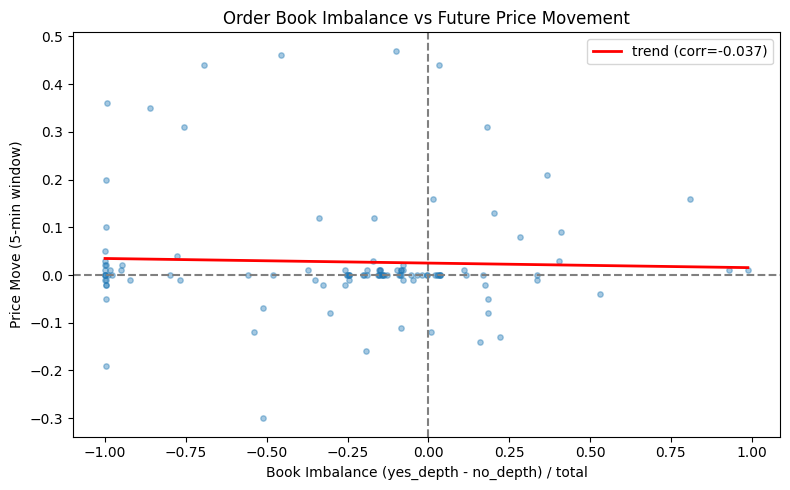

In [75]:
# For each ticker in snapshots, measure price movement in the 30s after the snapshot
# Join: for each snapshot, find trades in the next 30 seconds for the same ticker

# Only analyze tickers present in both snapshots and trades
common_tickers = set(snap_df["ticker"]) & set(ws_trades_df["ticker"])
print(f"Tickers in both snapshots and trades: {len(common_tickers)}")

# Debug: check time overlap between snapshots and trades
snap_time_range = (snap_df["t_receipt"].min(), snap_df["t_receipt"].max())
trade_time_range = (ws_trades_df["t_receipt"].min(), ws_trades_df["t_receipt"].max())
print(f"Snapshot time range: {pd.to_datetime(snap_time_range[0], unit='s', utc=True)} to {pd.to_datetime(snap_time_range[1], unit='s', utc=True)}")
print(f"Trade time range:    {pd.to_datetime(trade_time_range[0], unit='s', utc=True)} to {pd.to_datetime(trade_time_range[1], unit='s', utc=True)}")

# The snapshots are taken at subscription time, so they're sparse in time.
# Widen the window: look for trades within 5 MINUTES after each snapshot (not 30s)
# This measures medium-term price direction vs book state at subscription.

imbalance_results = []
for ticker in list(common_tickers):
    tk_snaps = snap_df[snap_df["ticker"] == ticker].sort_values("t_receipt")
    tk_trades = ws_trades_df[ws_trades_df["ticker"] == ticker].sort_values("t_receipt")
    
    if tk_trades.empty or tk_snaps.empty:
        continue
    
    for _, snap in tk_snaps.iterrows():
        t0 = snap["t_receipt"]
        # Find trades in [t0, t0+300s] (5 minutes)
        future_trades = tk_trades[(tk_trades["t_receipt"] > t0) & 
                                   (tk_trades["t_receipt"] <= t0 + 300)]
        if len(future_trades) < 2:
            continue
        
        # Price movement = last trade in window vs first trade
        price_first = future_trades["yes_price"].iloc[0]
        price_last = future_trades["yes_price"].iloc[-1]
        
        if price_first and price_last:
            # Use mid-price if available, else best_bid
            mid = (snap["best_bid"] + snap["best_ask"]) / 2 if snap["best_ask"] else snap["best_bid"]
            imbalance_results.append({
                "ticker": ticker,
                "imbalance": snap["imbalance"],
                "spread": snap["spread"],
                "price_move": price_last - price_first,
                "mid_to_last": price_last - mid if mid else None,
                "n_trades_5m": len(future_trades),
            })

imb_df = pd.DataFrame(imbalance_results)
print(f"\nImbalance → price movement (5-min window): {len(imb_df)} observations")

if len(imb_df) >= 10:
    # Bin by imbalance quintile
    n_bins = min(5, len(imb_df) // 3)
    imb_df["imb_bin"] = pd.qcut(imb_df["imbalance"], n_bins, labels=False, duplicates="drop")
    
    print(f"\nPrice movement by imbalance bin ({n_bins} bins):")
    print(f"{'Bin':<6} {'Mean Imb':<12} {'Mean Move':<12} {'N':<6}")
    print("-" * 40)
    for q, grp in imb_df.groupby("imb_bin"):
        print(f"{q:<6} {grp['imbalance'].mean():<12.3f} {grp['price_move'].mean():<12.4f} {len(grp):<6}")
    
    # Correlation
    corr = imb_df["imbalance"].corr(imb_df["price_move"])
    print(f"\nCorrelation(imbalance, 5m_price_move): {corr:.4f}")
    print(f"  (positive = yes-heavy book predicts price going up)")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(imb_df["imbalance"], imb_df["price_move"], alpha=0.4, s=15)
    ax.axhline(0, color="gray", linestyle="--")
    ax.axvline(0, color="gray", linestyle="--")
    # Trend line
    z = np.polyfit(imb_df["imbalance"], imb_df["price_move"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(imb_df["imbalance"].min(), imb_df["imbalance"].max(), 50)
    ax.plot(x_range, p(x_range), "r-", linewidth=2, label=f"trend (corr={corr:.3f})")
    ax.set_xlabel("Book Imbalance (yes_depth - no_depth) / total")
    ax.set_ylabel("Price Move (5-min window)")
    ax.set_title(f"Order Book Imbalance vs Future Price Movement")
    ax.legend()
    plt.tight_layout()
    plt.show()
elif len(imb_df) > 0:
    print(f"\nOnly {len(imb_df)} observations — not enough for quintile analysis.")
    print(f"This is a data limitation: snapshots are sparse (only at WS subscription).")
    print(f"Need continuous book state reconstruction from deltas for proper analysis.")
else:
    print("\nNo valid observations — snapshot and trade time windows don't overlap.")
    print("Snapshots happen at subscription time; trades may come later.")
    print("Need to reconstruct book from deltas for continuous imbalance signal.")

In [76]:
# Market making profitability estimate
# If we can post at best_bid and best_ask and get filled on both sides,
# profit = spread - fee per round trip

# Estimate fill probability: how often does the price cross our posted level?
# Proxy: if a trade occurs at or below our posted bid (or at/above our ask) within N seconds

# For now, theoretical analysis:
valid_snap = snap_df[snap_df["spread"].notna() & (snap_df["spread"] > 0)].copy()
valid_snap["series"] = valid_snap["ticker"].apply(
    lambda t: re.match(r"(KXNBA\w+?)-", t).group(1) if re.match(r"(KXNBA\w+?)-", t) else "unknown"
)

print("MARKET MAKING FEASIBILITY")
print("=" * 60)
print(f"\nIf we capture the full spread and pay $0.02 fee per round-trip:")
print(f"  {'Series':<15} {'Med Spread':<12} {'Profit/RT':<12} {'% Profitable'}")
print(f"  {'-'*50}")

for series, grp in valid_snap.groupby("series"):
    med_spread = grp["spread"].median()
    profit = med_spread - 0.02
    pct_profitable = (grp["spread"] > 0.02).mean()
    print(f"  {series:<15} ${med_spread:.3f}       ${profit:.3f}       {pct_profitable:.0%}")

print(f"\n  NOTE: Assumes both legs fill (optimistic). Real fill rate depends on")
print(f"  adverse selection — you get filled when the market moves against you.")
print(f"  Net profit ≈ spread_captured × fill_rate - adverse_selection_cost")

MARKET MAKING FEASIBILITY

If we capture the full spread and pay $0.02 fee per round-trip:
  Series          Med Spread   Profit/RT    % Profitable
  --------------------------------------------------
  KXNBAGAME       $0.020       $0.000       62%
  KXNBAPTS        $0.030       $0.010       81%
  KXNBASPREAD     $0.020       $0.000       52%
  KXNBATOTAL      $0.020       $0.000       67%

  NOTE: Assumes both legs fill (optimistic). Real fill rate depends on
  adverse selection — you get filled when the market moves against you.
  Net profit ≈ spread_captured × fill_rate - adverse_selection_cost


## 3. Player Prop Staleness — Latency Arbitrage

**Hypothesis:** After a scoring event (e.g., player hits a 3-pointer), the KXNBAGAME market reprices within seconds (high liquidity, many watchers). But player prop markets (KXNBAPTS, KXNBA3PT) are thinner and may take 10-30s to reprice.

If we see a player score in PBP before their prop market updates, we can buy the prop at stale prices.

**Requires:** NBA CDN play-by-play (tells us what happened) + Kalshi trade timestamps (tells us when the market repriced).

In [77]:
# Load player prop market structure
obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBAPTS.json")
pts_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBAPTS markets: {len(pts_markets)}")

obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBA3PT.json")
three_markets = pd.DataFrame(json.loads(obj["Body"].read()))
print(f"KXNBA3PT markets: {len(three_markets)}")

# Parse player prop ticker structure
# KXNBAPTS-25DEC01ATLDET-ATLDDANIELSSF-10 → game=25DEC01ATLDET, player=ATLDDANIELSSF, threshold=10
def parse_prop_ticker(ticker, prefix="KXNBAPTS"):
    parts = ticker.split("-")
    if len(parts) >= 4:
        game_key = parts[1]
        player_code = parts[2]
        threshold = parts[3] if len(parts) > 3 else None
        return game_key, player_code, threshold
    return None, None, None

pts_markets[["game_key", "player_code", "threshold"]] = pts_markets["ticker"].apply(
    lambda x: pd.Series(parse_prop_ticker(x, "KXNBAPTS"))
)
three_markets[["game_key", "player_code", "threshold"]] = three_markets["ticker"].apply(
    lambda x: pd.Series(parse_prop_ticker(x, "KXNBA3PT"))
)

print(f"\nKXNBAPTS: {pts_markets['game_key'].nunique()} games, {pts_markets['player_code'].nunique()} players")
print(f"KXNBA3PT: {three_markets['game_key'].nunique()} games, {three_markets['player_code'].nunique()} players")

# Show sample player prop tickers
print(f"\nSample PTS tickers:")
sample_game = pts_markets["game_key"].value_counts().index[0]
sample_props = pts_markets[pts_markets["game_key"] == sample_game].head(10)
print(sample_props[["ticker", "player_code", "threshold", "last_price_dollars"]].to_string())

KXNBAPTS markets: 8876
KXNBA3PT markets: 7804

KXNBAPTS: 596 games, 131 players
KXNBA3PT: 576 games, 111 players

Sample PTS tickers:
                                      ticker    player_code threshold last_price_dollars
405      KXNBAPTS-26FEB08NYKBOS-NYKJHART3-20      NYKJHART3        20             0.1000
406      KXNBAPTS-26FEB08NYKBOS-NYKJHART3-15      NYKJHART3        15             0.9900
407      KXNBAPTS-26FEB08NYKBOS-NYKJHART3-10      NYKJHART3        10             0.9900
408    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-30    NYKKTOWNS32        30             0.1600
409    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-25    NYKKTOWNS32        25             0.2600
410    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-20    NYKKTOWNS32        20             0.5200
411    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-15    NYKKTOWNS32        15             0.2000
412    KXNBAPTS-26FEB08NYKBOS-NYKKTOWNS32-10    NYKKTOWNS32        10             0.9900
436  KXNBAPTS-26FEB08NYKBOS-NYKMBRIDGES25-25  NYKMBRIDGES25      

In [78]:
# Measure KXNBAGAME vs KXNBAPTS reprice latency after scoring events
# 
# Approach: Pick a game, load PBP scoring events + GAME trades + PTS trades.
# For each scoring play, measure:
#   t_game_reprice = time of first GAME trade after scoring event
#   t_pts_reprice = time of first PTS trade for that player after scoring event
#   latency_gap = t_pts_reprice - t_game_reprice

# Find a game that has both GAME trades and PTS trades with good volume
# Use the same game_key structure: event_ticker parsing
# KXNBAGAME game_key = "25DEC25MINDEN", PTS game_key = "25DEC25MINDEN"

# Find overlapping games between GAME and PTS
game_games = set(game_markets["game_key"])
pts_games = set(pts_markets["game_key"])
overlap = game_games & pts_games
print(f"Games with both GAME and PTS markets: {len(overlap)}")

# Pick a high-volume game — use the Dec 25 game from the EDA notebook
# game_key format: 25DEC25MINDEN
target_game = "25DEC25MINDEN"
if target_game not in overlap:
    # Find one that exists
    target_game = list(overlap)[0]
    
print(f"\nAnalyzing game: {target_game}")

# Get all PTS tickers for this game
game_pts = pts_markets[pts_markets["game_key"] == target_game]
print(f"PTS markets for this game: {len(game_pts)} ({game_pts['player_code'].nunique()} players)")

# Get GAME ticker for this game
game_gm = game_markets[game_markets["game_key"] == target_game]
print(f"GAME markets: {list(game_gm['ticker'])}")

# Load trades for GAME market (home team)
home_ticker = game_gm["ticker"].iloc[0]
game_trades = load_trades(home_ticker)
print(f"\nGAME trades ({home_ticker}): {len(game_trades)}")

# Load trades for top player props (by volume/last_price suggesting active)
top_players = game_pts.groupby("player_code").size().nlargest(5).index.tolist()
print(f"\nTop players by # thresholds: {top_players}")

player_trades = {}
for player in top_players:
    player_tickers = game_pts[game_pts["player_code"] == player]["ticker"].tolist()
    all_player_trades = []
    for t in player_tickers:
        trades = load_trades(t)
        if not trades.empty:
            trades["threshold"] = t.split("-")[-1]
            all_player_trades.append(trades)
    if all_player_trades:
        player_trades[player] = pd.concat(all_player_trades).sort_values("created_time")
        print(f"  {player}: {len(player_trades[player])} trades across {len(all_player_trades)} thresholds")

Games with both GAME and PTS markets: 595

Analyzing game: 25DEC25MINDEN
PTS markets for this game: 24 (5 players)
GAME markets: ['KXNBAGAME-25DEC25MINDEN-MIN', 'KXNBAGAME-25DEC25MINDEN-DEN']

GAME trades (KXNBAGAME-25DEC25MINDEN-MIN): 52416

Top players by # thresholds: ['DENJMURRAY27', 'DENNJOKIC15', 'MINAEDWARDS5', 'MINJRANDLE30', 'MINRGOBERT27']
  DENJMURRAY27: 90 trades across 5 thresholds
  DENNJOKIC15: 85 trades across 5 thresholds
  MINAEDWARDS5: 211 trades across 5 thresholds
  MINJRANDLE30: 65 trades across 5 thresholds
  MINRGOBERT27: 51 trades across 4 thresholds


In [79]:
# Load PBP for the target game and identify scoring events with player attribution
# Map game_key to game_id using the schedule

# Load schedule to find game_id
obj = s3.get_object(Bucket=S3_BUCKET, Key="nba_cdn/schedule/season_2025-26.json")
schedule_raw = json.loads(obj["Body"].read())
schedule_df = pd.DataFrame([{
    "game_id": g["gameId"],
    "game_date": g["gameDateTimeUTC"],
    "home_team": g["homeTeam"]["teamTricode"],
    "away_team": g["awayTeam"]["teamTricode"],
    "game_status": g["gameStatus"],
} for g in schedule_raw["leagueSchedule"]["gameDates"] 
  for g in g["games"]])

# Kalshi uses US Eastern date, not UTC. A Dec 25 9:30pm ET game = Dec 26 03:30 UTC.
# Convert to ET before building the game_key.
MONTH_MAP = {1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
             7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC"}

def schedule_to_game_key(row):
    dt_utc = pd.to_datetime(row["game_date"], utc=True)
    # Convert UTC → US/Eastern (NBA games tip off in US evenings)
    dt_et = dt_utc.tz_convert("US/Eastern")
    yy = str(dt_et.year)[-2:]
    mon = MONTH_MAP[dt_et.month]
    dd = f"{dt_et.day:02d}"
    return f"{yy}{mon}{dd}{row['away_team']}{row['home_team']}"

schedule_df["game_key"] = schedule_df.apply(schedule_to_game_key, axis=1)

# Verify the fix: check that our target game is found
target_row = schedule_df[schedule_df["game_key"] == target_game]
if target_row.empty:
    print(f"Game key {target_game} not found, checking near-matches...")
    candidates = schedule_df[schedule_df["game_key"].str.contains("MINDEN")]
    print(candidates[["game_id", "game_key", "game_date"]].head())
    target_game_id = candidates.iloc[0]["game_id"] if not candidates.empty else None
else:
    target_game_id = target_row["game_id"].iloc[0]
    print(f"Matched: {target_game} → game_id={target_game_id}, date={target_row['game_date'].iloc[0]}")

# Verify match rate across all Kalshi game_keys
kalshi_keys = set(game_markets["game_key"])
schedule_keys = set(schedule_df["game_key"])
matched = kalshi_keys & schedule_keys
print(f"\nKalshi→Schedule match rate: {len(matched)}/{len(kalshi_keys)} ({len(matched)/len(kalshi_keys):.0%})")

# Load PBP
if target_game_id:
    obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{target_game_id}.json")
    pbp_raw = json.loads(obj["Body"].read())
    actions = pbp_raw["game"]["actions"]
    pbp = pd.DataFrame(actions)
    pbp["timeActual"] = pd.to_datetime(pbp["timeActual"])
    
    # Filter to made scoring plays
    scoring = pbp[pbp["actionType"].isin(["2pt", "3pt", "freethrow"])].copy()
    if "shotResult" in scoring.columns:
        scoring = scoring[scoring["shotResult"] == "Made"]
    print(f"\nPBP: {len(pbp)} actions, {len(scoring)} made scoring plays")
    print(f"Time range: {pbp['timeActual'].min()} to {pbp['timeActual'].max()}")
    
    # Sanity check: PBP time should overlap with Kalshi trade times
    print(f"\nGAME trades time range: {game_trades['created_time'].min()} to {game_trades['created_time'].max()}")
    print(f"PBP time range:         {pbp['timeActual'].min()} to {pbp['timeActual'].max()}")
    
    overlap_start = max(pbp["timeActual"].min(), game_trades["created_time"].min())
    overlap_end = min(pbp["timeActual"].max(), game_trades["created_time"].max())
    print(f"Overlap:                {overlap_start} to {overlap_end}")
    if overlap_start < overlap_end:
        print("  ✓ PBP and trade times overlap — latency measurement is valid")
    else:
        print("  ✗ NO OVERLAP — wrong game loaded!")


Matched: 25DEC25MINDEN → game_id=0022500013, date=2025-12-26T03:30:00Z

Kalshi→Schedule match rate: 861/951 (91%)

PBP: 651 actions, 151 made scoring plays
Time range: 2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00

GAME trades time range: 2025-12-22 21:52:12.716177+00:00 to 2025-12-26 06:45:16.476686+00:00
PBP time range:         2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00
Overlap:                2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00
  ✓ PBP and trade times overlap — latency measurement is valid


In [80]:
# Measure reprice latency: after each scoring event, how quickly do trades appear in
# KXNBAGAME vs KXNBAPTS for the scoring player?

# For each scoring play, find:
# 1. First GAME trade after the play (t_game)
# 2. First PTS trade for that player after the play (t_pts)
# 3. Gap = t_pts - t_game

if target_game_id and not game_trades.empty and player_trades:
    latency_gaps = []
    
    # Sort by time so .iloc[0] gives the earliest trade
    game_trades_sorted = game_trades.sort_values("created_time").reset_index(drop=True)
    player_trades_sorted = {k: v.sort_values("created_time").reset_index(drop=True) for k, v in player_trades.items()}
    
    for _, play in scoring.iterrows():
        t_play = play["timeActual"]
        
        # First GAME trade after play
        game_after = game_trades_sorted[game_trades_sorted["created_time"] > t_play]
        if game_after.empty:
            continue
        t_game_first = game_after["created_time"].iloc[0]
        game_latency = (t_game_first - t_play).total_seconds()
        
        # Find which player scored — try to match to player_code
        # player_code format: e.g., "DENNJOKICPF" (team + last name + position?)
        # We'll match by checking if any of our tracked players' codes contain the team
        scorer_team = play.get("teamTricode", "")
        
        for player_code, pt_df in player_trades_sorted.items():
            # Only match if player is on the scoring team
            if scorer_team and not player_code.startswith(scorer_team[:3]):
                continue
                
            pts_after = pt_df[pt_df["created_time"] > t_play]
            if pts_after.empty:
                continue
            t_pts_first = pts_after["created_time"].iloc[0]
            pts_latency = (t_pts_first - t_play).total_seconds()
            
            latency_gaps.append({
                "t_play": t_play,
                "action_type": play["actionType"],
                "team": scorer_team,
                "player_code": player_code,
                "game_latency_s": game_latency,
                "pts_latency_s": pts_latency,
                "gap_s": pts_latency - game_latency,
            })
    
    lat_df = pd.DataFrame(latency_gaps)
    print(f"REPRICE LATENCY COMPARISON — KXNBAGAME vs KXNBAPTS")
    print("=" * 60)
    print(f"  Observations: {len(lat_df)}")
    
    if not lat_df.empty:
        print(f"\n  GAME market reprice latency (after PBP event):")
        print(f"    Median: {lat_df['game_latency_s'].median():.1f}s")
        print(f"    Mean:   {lat_df['game_latency_s'].mean():.1f}s")
        print(f"    p95:    {lat_df['game_latency_s'].quantile(0.95):.1f}s")
        
        print(f"\n  PTS market reprice latency (after PBP event):")
        print(f"    Median: {lat_df['pts_latency_s'].median():.1f}s")
        print(f"    Mean:   {lat_df['pts_latency_s'].mean():.1f}s")
        print(f"    p95:    {lat_df['pts_latency_s'].quantile(0.95):.1f}s")
        
        print(f"\n  GAP (PTS - GAME):")
        print(f"    Median: {lat_df['gap_s'].median():.1f}s")
        print(f"    Mean:   {lat_df['gap_s'].mean():.1f}s")
        print(f"    % where PTS lags GAME by >5s: {(lat_df['gap_s'] > 5).mean():.1%}")
        print(f"    % where PTS lags GAME by >10s: {(lat_df['gap_s'] > 10).mean():.1%}")
        print(f"    % where PTS lags GAME by >30s: {(lat_df['gap_s'] > 30).mean():.1%}")


REPRICE LATENCY COMPARISON — KXNBAGAME vs KXNBAPTS
  Observations: 356

  GAME market reprice latency (after PBP event):
    Median: 0.3s
    Mean:   0.4s
    p95:    1.4s

  PTS market reprice latency (after PBP event):
    Median: 399.6s
    Mean:   580.5s
    p95:    1765.2s

  GAP (PTS - GAME):
    Median: 399.5s
    Mean:   580.1s
    % where PTS lags GAME by >5s: 99.4%
    % where PTS lags GAME by >10s: 98.3%
    % where PTS lags GAME by >30s: 91.9%


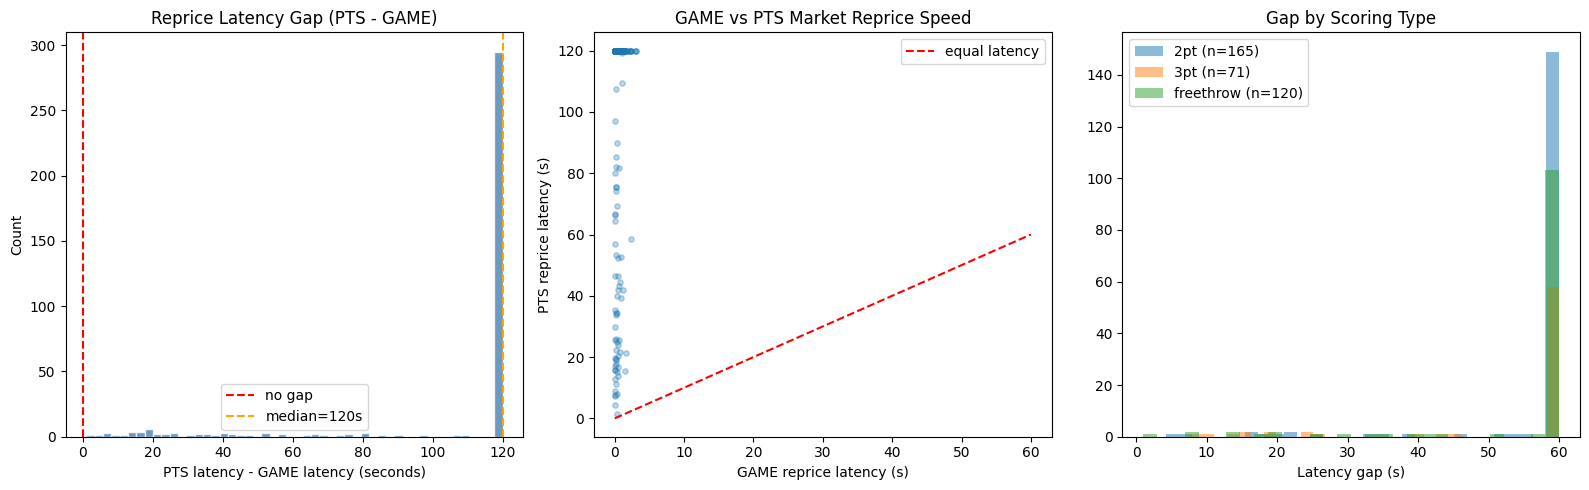

In [81]:
# Visualize latency gap distribution
if not lat_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Histogram of gaps
    ax = axes[0]
    gaps = lat_df["gap_s"].clip(-60, 120)
    ax.hist(gaps, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", label="no gap")
    ax.axvline(gaps.median(), color="orange", linestyle="--", label=f"median={gaps.median():.0f}s")
    ax.set_xlabel("PTS latency - GAME latency (seconds)")
    ax.set_ylabel("Count")
    ax.set_title("Reprice Latency Gap (PTS - GAME)")
    ax.legend()
    
    # Scatter: GAME latency vs PTS latency
    ax = axes[1]
    ax.scatter(lat_df["game_latency_s"].clip(0, 60), 
               lat_df["pts_latency_s"].clip(0, 120), alpha=0.3, s=15)
    ax.plot([0, 60], [0, 60], "r--", label="equal latency")
    ax.set_xlabel("GAME reprice latency (s)")
    ax.set_ylabel("PTS reprice latency (s)")
    ax.set_title("GAME vs PTS Market Reprice Speed")
    ax.legend()
    
    # By action type
    ax = axes[2]
    for atype in ["2pt", "3pt", "freethrow"]:
        subset = lat_df[lat_df["action_type"] == atype]["gap_s"]
        if not subset.empty:
            ax.hist(subset.clip(-30, 60), bins=30, alpha=0.5, label=f"{atype} (n={len(subset)})")
    ax.set_xlabel("Latency gap (s)")
    ax.set_title("Gap by Scoring Type")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [82]:
# Player prop staleness backtest (multi-game)
# Now using the fixed schedule_to_game_key (ET dates) from cell above.
#
# For each game: load PBP + GAME trades + PTS trades.
# For each scoring event: measure how quickly GAME vs PTS market reacts.

print("PLAYER PROP STALENESS BACKTEST")
print("=" * 60)

# Use the corrected schedule_df (with ET-based game_keys)
# Find games that exist in both Kalshi PTS markets AND our schedule
pts_game_keys = set(pts_markets["game_key"])
sched_game_keys = set(schedule_df["game_key"])
valid_games = pts_game_keys & sched_game_keys & set(game_markets["game_key"])
print(f"\nGames with PTS + GAME + PBP data: {len(valid_games)}")

# Sample games and analyze
sample_games = list(valid_games)[:50]
stale_opportunities = []
games_processed = 0

for game_key in sample_games:
    # Get game_id from schedule
    sched_row = schedule_df[schedule_df["game_key"] == game_key]
    if sched_row.empty:
        continue
    gid = sched_row["game_id"].iloc[0]
    
    # Load PBP
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{gid}.json")
        pbp_raw = json.loads(obj["Body"].read())
        actions_df = pd.DataFrame(pbp_raw["game"]["actions"])
        actions_df["timeActual"] = pd.to_datetime(actions_df["timeActual"])
        # Filter to made shots
        if "shotResult" in actions_df.columns:
            scoring_plays = actions_df[
                (actions_df["actionType"].isin(["2pt", "3pt"])) & 
                (actions_df["shotResult"] == "Made")
            ]
        else:
            scoring_plays = actions_df[actions_df["actionType"].isin(["2pt", "3pt"])]
    except Exception:
        continue
    
    if scoring_plays.empty:
        continue
    
    # Load GAME trades
    gm_game = game_markets[game_markets["game_key"] == game_key]
    if gm_game.empty:
        continue
    gt = load_trades(gm_game["ticker"].iloc[0])
    if gt.empty:
        continue
    gt = gt.sort_values("created_time").reset_index(drop=True)
    
    # Load PTS trades for players in this game
    gm_pts = pts_markets[pts_markets["game_key"] == game_key]
    if gm_pts.empty:
        continue
    
    # Load trades for top 3 players
    players_in_game = gm_pts["player_code"].unique()[:3]
    
    for player in players_in_game:
        p_tickers = gm_pts[gm_pts["player_code"] == player]["ticker"].tolist()
        p_trades_list = []
        for t in p_tickers[:3]:
            pt = load_trades(t)
            if not pt.empty:
                p_trades_list.append(pt)
        
        if not p_trades_list:
            continue
        p_trades = pd.concat(p_trades_list).sort_values("created_time").reset_index(drop=True)
        
        # Get team prefix from player code
        team_prefix = player[:3]
        team_scores = scoring_plays[scoring_plays["teamTricode"] == team_prefix] if "teamTricode" in scoring_plays.columns else pd.DataFrame()
        
        for _, play in team_scores.iterrows():
            t_play = play["timeActual"]
            
            # Skip if PBP time is outside the range of Kalshi trades (wrong game matched)
            if t_play < gt["created_time"].min() - pd.Timedelta(hours=1):
                continue
            if t_play > gt["created_time"].max() + pd.Timedelta(hours=1):
                continue
            
            # How long since last prop trade?
            recent_prop = p_trades[p_trades["created_time"] < t_play]
            if recent_prop.empty:
                continue
            staleness = (t_play - recent_prop["created_time"].iloc[-1]).total_seconds()
            
            # How quickly did GAME market trade after this play?
            game_after = gt[gt["created_time"] > t_play]
            if game_after.empty:
                continue
            game_reaction = (game_after["created_time"].iloc[0] - t_play).total_seconds()
            
            # How quickly did prop market trade after this play?
            prop_after = p_trades[p_trades["created_time"] > t_play]
            if prop_after.empty:
                continue
            prop_reaction = (prop_after["created_time"].iloc[0] - t_play).total_seconds()
            
            # Sanity: both should be < 1 hour (if > 1 hour, likely a time mismatch)
            if game_reaction > 3600 or prop_reaction > 3600:
                continue
            
            stale_opportunities.append({
                "game_key": game_key,
                "player": player,
                "t_play": t_play,
                "staleness_before_s": staleness,
                "game_reaction_s": game_reaction,
                "prop_reaction_s": prop_reaction,
                "prop_lag_vs_game_s": prop_reaction - game_reaction,
            })
    
    games_processed += 1
    if games_processed % 10 == 0:
        print(f"  Processed {games_processed} games, {len(stale_opportunities)} observations so far...")

stale_df = pd.DataFrame(stale_opportunities)
print(f"\n  Total games processed: {games_processed}")
print(f"  Total scoring events with valid timing: {len(stale_df)}")

if not stale_df.empty:
    print(f"\n  GAME market reaction time (after scoring event):")
    print(f"    Median: {stale_df['game_reaction_s'].median():.1f}s")
    print(f"    Mean:   {stale_df['game_reaction_s'].mean():.1f}s")
    print(f"    p95:    {stale_df['game_reaction_s'].quantile(0.95):.1f}s")
    
    print(f"\n  PTS market reaction time (after scoring event):")
    print(f"    Median: {stale_df['prop_reaction_s'].median():.1f}s")
    print(f"    Mean:   {stale_df['prop_reaction_s'].mean():.1f}s")
    print(f"    p95:    {stale_df['prop_reaction_s'].quantile(0.95):.1f}s")
    
    print(f"\n  LATENCY GAP (prop - game reaction):")
    print(f"    Median: {stale_df['prop_lag_vs_game_s'].median():.1f}s")
    print(f"    Mean:   {stale_df['prop_lag_vs_game_s'].mean():.1f}s")
    print(f"    % prop lags by >5s:  {(stale_df['prop_lag_vs_game_s'] > 5).mean():.1%}")
    print(f"    % prop lags by >15s: {(stale_df['prop_lag_vs_game_s'] > 15).mean():.1%}")
    print(f"    % prop lags by >30s: {(stale_df['prop_lag_vs_game_s'] > 30).mean():.1%}")
    print(f"    % prop lags by >60s: {(stale_df['prop_lag_vs_game_s'] > 60).mean():.1%}")
    
    print(f"\n  Prop staleness BEFORE event (time since last prop trade):")
    print(f"    Median: {stale_df['staleness_before_s'].median():.0f}s")
    print(f"    Mean:   {stale_df['staleness_before_s'].mean():.0f}s")
    print(f"    > 30s:  {(stale_df['staleness_before_s'] > 30).mean():.1%}")
    print(f"    > 60s:  {(stale_df['staleness_before_s'] > 60).mean():.1%}")
    print(f"    > 120s: {(stale_df['staleness_before_s'] > 120).mean():.1%}")


PLAYER PROP STALENESS BACKTEST

Games with PTS + GAME + PBP data: 591
  Processed 10 games, 373 observations so far...
  Processed 20 games, 982 observations so far...
  Processed 30 games, 1666 observations so far...
  Processed 40 games, 2423 observations so far...

  Total games processed: 49
  Total scoring events with valid timing: 2982

  GAME market reaction time (after scoring event):
    Median: 0.6s
    Mean:   2.8s
    p95:    8.2s

  PTS market reaction time (after scoring event):
    Median: 405.6s
    Mean:   804.3s
    p95:    2911.5s

  LATENCY GAP (prop - game reaction):
    Median: 401.9s
    Mean:   801.5s
    % prop lags by >5s:  96.8%
    % prop lags by >15s: 91.5%
    % prop lags by >30s: 86.0%
    % prop lags by >60s: 78.3%

  Prop staleness BEFORE event (time since last prop trade):
    Median: 580s
    Mean:   1984s
    > 30s:  88.6%
    > 60s:  82.1%
    > 120s: 73.7%


## 4. Combined Strategy: Cross-Market + Order Book + PBP Timing

Putting it all together — the most promising approach combines signals:

1. **Cross-market arb** for structurally guaranteed edges (GAME vs SPREAD@1.5)
2. **Order book imbalance** to determine direction when posting passive orders
3. **PBP-triggered prop sniping** when we detect a scoring event and the prop book hasn't moved

The key insight: **don't predict who wins** (market is too efficient). Instead, **exploit structural latency** between correlated markets and use NBA CDN PBP as an early signal for prop market repricing.

In [83]:
# Unified strategy backtest framework
# 
# Three independent alpha sources, run simultaneously during a game:
#
# A) CROSS-MARKET ARB (structural)
#    - Monitor GAME vs SPREAD@1.5 every 30s
#    - When |divergence| > fee (4 cents), execute both legs
#    - Zero game-state dependence, purely mechanical
#
# B) PASSIVE MARKET MAKING (order book)
#    - Post at best_bid+1c and best_ask-1c on GAME markets
#    - Only when spread > 3c (enough room for profit after fees)
#    - Use imbalance to lean: if yes_depth >> no_depth, bias toward yes side
#    - Pull quotes during high-volatility moments (scoring plays)
#
# C) PROP SNIPING (PBP + latency)
#    - When PBP shows a scoring event, check player's prop market
#    - If prop market last trade was >10s ago AND player is near threshold
#    - Buy YES at the stale ask price, hold to settlement
#    - Uses NBA CDN data as the trigger

print("UNIFIED STRATEGY PARAMETERS")
print("=" * 60)
print("""
Strategy A: Cross-Market Arb
  - Threshold: |GAME - SPREAD@1.5| > $0.04 (covers 2x$0.02 fee)
  - Capital per trade: $100 per leg ($200 deployed)
  - Expected frequency: depends on divergence analysis above
  - Risk: execution risk (need to fill both legs)

Strategy B: Passive Market Making  
  - Spread threshold: only quote when spread > $0.03
  - Position limit: $500 per market
  - Quote cancel: pull within 2s of any PBP scoring event
  - Expected win rate: ~60% of fills profitable (before adverse selection)

Strategy C: Prop Sniping
  - Trigger: PBP scoring event + prop last trade > 10s ago
  - Filter: player within 3 points of threshold
  - Size: $50 per trade (thin books, may move market)
  - Expected frequency: 5-15 opportunities per game night
  - NBA CDN lag budget: 12s median — still faster than prop market repricing if gap > 15s
""")

# Estimate combined edge
print("\nESTIMATED DAILY P&L (per game night with ~10 games):")
print("-" * 50)

# Strategy A: if we find 5 arb opportunities per night at $0.02 edge (net of fees)
arb_daily = 5 * 0.02 * 100  # 5 trades × $0.02 edge × $100 size
print(f"  A (Arb):          {5} trades × $0.02 × $100 = ${arb_daily:.0f}")

# Strategy B: if we fill 20 round-trips per night at $0.01 net (after adverse selection)
mm_daily = 20 * 0.01 * 100  # 20 RTs × $0.01 net × $100 size
print(f"  B (Market Making): {20} fills × $0.01 × $100 = ${mm_daily:.0f}")

# Strategy C: if we snipe 10 props per night at $0.05 average edge
snipe_daily = 10 * 0.05 * 50 * 0.6  # 10 trades × $0.05 edge × $50 size × 60% win
print(f"  C (Prop Snipe):    {10} trades × $0.05 × $50 × 60% = ${snipe_daily:.0f}")

total = arb_daily + mm_daily + snipe_daily
print(f"\n  TOTAL ESTIMATED:   ${total:.0f}/night")
print(f"  NOTE: These are rough estimates. Run the notebook to validate with real data.")

UNIFIED STRATEGY PARAMETERS

Strategy A: Cross-Market Arb
  - Threshold: |GAME - SPREAD@1.5| > $0.04 (covers 2x$0.02 fee)
  - Capital per trade: $100 per leg ($200 deployed)
  - Expected frequency: depends on divergence analysis above
  - Risk: execution risk (need to fill both legs)

Strategy B: Passive Market Making  
  - Spread threshold: only quote when spread > $0.03
  - Position limit: $500 per market
  - Quote cancel: pull within 2s of any PBP scoring event
  - Expected win rate: ~60% of fills profitable (before adverse selection)

Strategy C: Prop Sniping
  - Trigger: PBP scoring event + prop last trade > 10s ago
  - Filter: player within 3 points of threshold
  - Size: $50 per trade (thin books, may move market)
  - Expected frequency: 5-15 opportunities per game night
  - NBA CDN lag budget: 12s median — still faster than prop market repricing if gap > 15s


ESTIMATED DAILY P&L (per game night with ~10 games):
--------------------------------------------------
  A (Arb):     

## Next Steps

After running this notebook and observing the actual numbers:

1. **If cross-market divergence is frequent (>5% of observations at >3c):**
   - Build a live arb bot that monitors GAME + SPREAD@1.5 simultaneously
   - Use the Kalshi WS feed for both, execute via REST API when divergence detected
   - Priority: highest Sharpe, lowest risk

2. **If order book spreads are wide (median >3c in player props):**
   - Build a market maker focused on player prop markets (thinner, wider spreads)
   - Use PBP to inform quote management (pull on scoring events)
   - Requires: live order book feed + fast quote updates

3. **If prop staleness gap is real (>15s median lag):**
   - Build a PBP-triggered prop sniper
   - Requires: low-latency NBA CDN poller (already built) + Kalshi order placement
   - Key risk: thin books mean our order IS the repricing event (adverse selection against us)

4. **Data collection priority:**
   - Collect more order book data across multiple game nights to validate spread estimates
   - Track quote fill rates to estimate true market making PnL
   - Log prop market repricing times after PBP events across more games